# Pipeline Tag Prediction

## Model B: Modern BERT
**DATASCI 266: Natural Language Processing with Deep Learning**

UC Berkeley, School of Information

---

This notebook implements an improvement model over the baseline using modernBERT-base with truncation to 512 tokens. It runs in this order:

1. Load split dataframes used in baseline
2. Setup tokenizer
3. Setup HuggingFace Datasets
4. Data collator for dynamic padding
5. ModernBERT model
6. Train model w/ data-scaling ablation experiments
7. Predictions and metric analysis
8. Save the fine-tuned model and results


## 0. Setup

In [1]:
!pip install -q -U transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 126.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 53.6 MB/s eta 0:00:00


In [2]:
import os, gc, shutil, warnings, json
import numpy as np
import pandas as pd
import torch
import evaluate
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)

warnings.filterwarnings("ignore")

SEED = 42
set_seed(SEED)

# Plot defaults
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (12, 5)})

device = torch.device("cuda")
print("GPU:", torch.cuda.get_device_name(0))
print("VRAM: {:.1f} GB".format(torch.cuda.get_device_properties(0).total_memory / 1e9))
print("Libraries loaded ✓")


GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB
Libraries loaded ✓


## 1. Load DataFrames

Import the train, test, and validation dataframes that were used for the baseline. They underwent an 80/10/10 split. This ensures we are using the same exact dataset across all models to best inform our model and error analysis.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR_2 = '/content/drive/MyDrive/266-pipeline-tag-prediction'

train_df = pd.read_parquet(f'{DRIVE_DIR_2}/train_df.parquet')
val_df = pd.read_parquet(f'{DRIVE_DIR_2}/val_df.parquet')
test_df = pd.read_parquet(f'{DRIVE_DIR_2}/test_df.parquet')

metadata = json.load(open(f'{DRIVE_DIR_2}/metadata.json'))
label2id, id2label = metadata['label2id'], metadata['id2label']

Mounted at /content/drive


In [4]:
# Verify shapes for each df
print("Shape of train:", train_df.shape)
print("Shape of validation:", val_df.shape)
print("Shape of test:", test_df.shape)

Shape of train: (116002, 7)
Shape of validation: (14501, 7)
Shape of test: (14500, 7)


## 2. Tokenizer

ModernBERT-base supports up to an 8,192-token context. We limit the context window based on the actual distribution of model-card text lengths rather than defaulting to the full context window to preserve memory so the T4 GPU does not fail to support the model training.

In [5]:
# Load tokenizer from ModernBERT-base
modernBERT_checkpoint = "answerdotai/ModernBERT-base"
modernBERT_tokenizer = AutoTokenizer.from_pretrained(modernBERT_checkpoint)

config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

In [7]:
def tokenize_batch(batch):
    tokenized = modernBERT_tokenizer(
        batch["text"],
        truncation=True,
        max_length=512,
    )
    tokenized["length"] = [len(ids) for ids in tokenized["input_ids"]]
    return tokenized

tokenize_kwargs = dict(
    batched=True,
    batch_size=1000,
    num_proc=max(1, os.cpu_count() - 1),
    remove_columns=["text"],
)

## 3. Convert DataFrames into pre-tokenized Hugging Face Dataset objects

Setup the data to be usable by the tokenizer, model, and trainer.

In [8]:
# Convert DataFrames to Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False)
val_dataset = Dataset.from_pandas(val_df[["text", "label"]], preserve_index=False)
test_dataset = Dataset.from_pandas(test_df[["text", "label"]], preserve_index=False)

In [9]:
train_dataset = train_dataset.map(tokenize_batch, **tokenize_kwargs)
val_dataset = val_dataset.map(tokenize_batch, **tokenize_kwargs)
test_dataset = test_dataset.map(tokenize_batch, **tokenize_kwargs)

train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

print(train_dataset)

Map (num_proc=11):   0%|          | 0/116002 [00:00<?, ? examples/s]

Map (num_proc=11):   0%|          | 0/14501 [00:00<?, ? examples/s]

Map (num_proc=11):   0%|          | 0/14500 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'attention_mask', 'length'],
    num_rows: 116002
})


## 4. Data Collator

Setup dynamic padding to the longest sequence per batch to maximize compatibility with the current T4 GPU environment.

In [10]:
data_collator = DataCollatorWithPadding(
    tokenizer=modernBERT_tokenizer,
    padding="longest",
    pad_to_multiple_of=8,
)

## 5. ModernBERT Model


In [11]:
num_labels = len(label2id)
class_names = [id2label[str(i)] for i in range(num_labels)]

# Setup metrics - accuracy, macro F1, and weighted F1
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }


## 6. Train (with Data-Scaling Ablation Experiments)

Beyond training on the full dataset, we run a data-scaling ablation to understand how ModernBERT's performance varies with training set size. The model is trained separately on 25%, 50%, 75%, and 100% of the training data.


Uncomment the block below to check GPU usage while training is running.


In [12]:
# import subprocess, threading, time

# def log_gpu(interval=5, duration=60):
#     end = time.time() + duration
#     while time.time() < end:
#         out = subprocess.run(
#             ["nvidia-smi", "--query-gpu=utilization.gpu,memory.used", "--format=csv,noheader"],
#             capture_output=True, text=True
#         )
#         print(out.stdout.strip())
#         time.sleep(interval)

# threading.Thread(target=log_gpu, daemon=True).start()


In [13]:
train_fraction = [0.25, 0.50, 0.75, 1.00]
ablation_results = []

for i in train_fraction:
    print(f"\n=== Training ModernBERT-base on {int(i * 100)}% of training data ===")

    n_samples = int(len(train_dataset) * i)
    train_subset = train_dataset.shuffle(seed=SEED).select(range(n_samples))

    # Fresh model per run so each data-scaling point starts from the same pretrained weights
    modernBERT_model = AutoModelForSequenceClassification.from_pretrained(
        modernBERT_checkpoint,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        attn_implementation="sdpa",
    )

    training_args = TrainingArguments(
        output_dir=f'./results_{int(i * 100)}pct',
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        gradient_accumulation_steps=2,
        num_train_epochs=1,
        weight_decay=0.01,
        load_best_model_at_end=True,
        fp16=True,
        dataloader_num_workers=2,
        dataloader_pin_memory=True,
        optim="adamw_torch_fused",
    )

    trainer = Trainer(
        model=modernBERT_model,
        args=training_args,
        train_dataset=train_subset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        data_collator=data_collator
    )

    # Run train
    trainer.train()

    # Evaluate test per data-scaling run
    test_metrics = trainer.evaluate(eval_dataset=test_dataset)

    ablation_results.append({
        "model": "ModernBERT-base",
        "train_fraction": i,
        "train_samples": n_samples,
        "accuracy": test_metrics["eval_accuracy"],
        "macro_f1": test_metrics["eval_macro_f1"],
        "weighted_f1": test_metrics["eval_weighted_f1"],
    })

    # storing per-class F1 for each run again - similar to baseline / RoBERTa
    test_predictions = trainer.predict(test_dataset)
    preds = np.argmax(test_predictions.predictions, axis=-1)
    true_labels = test_predictions.label_ids
    per_class_f1 = f1_score(true_labels, preds, average=None, labels=range(num_labels))
    ablation_results[-1]["per_class_f1"] = dict(zip(class_names, per_class_f1))


=== Training ModernBERT-base on 25% of training data ===


model.safetensors: reconstructing file:   0%|          |  0.00B /  599MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.249859,0.116468,0.963106,0.961401,0.963015


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.249859,0.117442,1,0.965448,0.963720,0.965335


## 7. Predictions and Metric Analysis


In [14]:
# Data-scaling ablation results (accuracy, macro F1, weighted F1 per training fraction)
ablation_df = pd.DataFrame(ablation_results)
ablation_df

,model,train_fraction,train_samples,accuracy,macro_f1,weighted_f1,per_class_f1
0,ModernBERT-base,0.25,29000,0.937793,0.930778,0.936081,{'automatic-speech-recognition': 0.97233201581...
1,ModernBERT-base,0.50,58001,0.955310,0.952728,0.954807,{'automatic-speech-recognition': 0.98435054773...
2,ModernBERT-base,0.75,87001,0.959793,0.958680,0.959513,{'automatic-speech-recognition': 0.98744113029...
3,ModernBERT-base,1.00,116002,0.965448,0.963720,0.965335,{'automatic-speech-recognition': 0.98825371965...


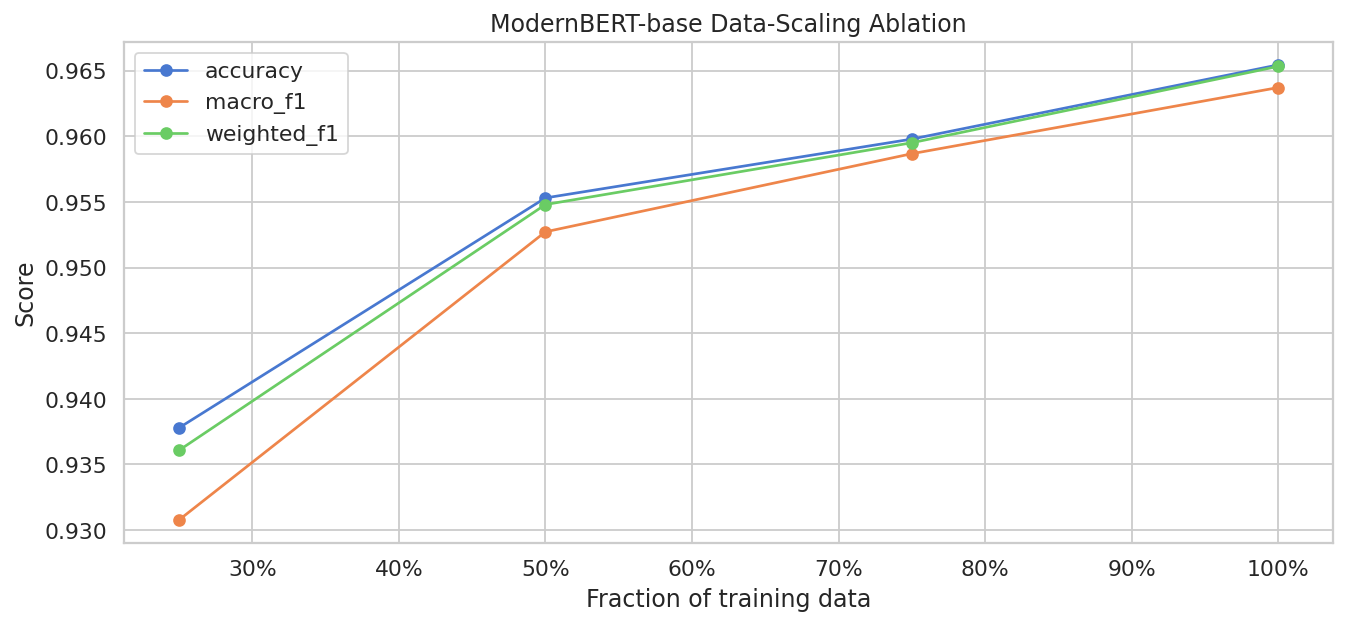

In [15]:
# Plot learning curves: metric vs. training data fraction
fig, ax = plt.subplots()
for metric_name in ["accuracy", "macro_f1", "weighted_f1"]:
    ax.plot(ablation_df["train_fraction"], ablation_df[metric_name], marker="o", label=metric_name)

ax.set_xlabel("Fraction of training data")
ax.set_ylabel("Score")
ax.set_title("ModernBERT-base Data-Scaling Ablation")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.legend()

fig.savefig(f'{DRIVE_DIR_2}/modernbert_learning_curves.png', dpi=150, bbox_inches="tight")

plt.show()

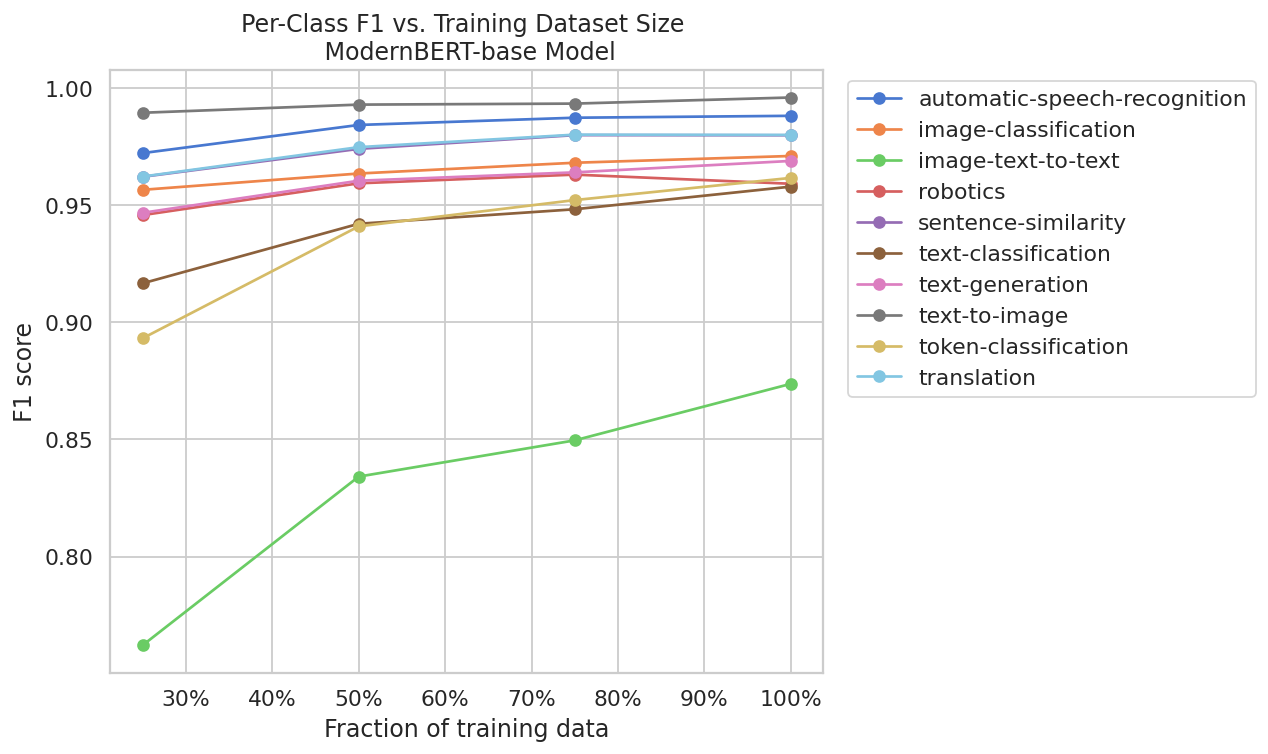

In [16]:
# Per class F1 - does it improve with more data?
per_class_df = pd.DataFrame([r["per_class_f1"] for r in ablation_results])
per_class_df["train_fraction"] = ablation_df["train_fraction"]

fig, ax = plt.subplots(figsize=(10, 6))
for class_name in class_names:
    ax.plot(per_class_df["train_fraction"], per_class_df[class_name], marker="o", label=class_name)

ax.set_xlabel("Fraction of training data")
ax.set_ylabel("F1 score")
ax.set_title("Per-Class F1 vs. Training Dataset Size \n ModernBERT-base Model")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

fig.savefig(f'{DRIVE_DIR_2}/modernbert_per_class_f1.png', dpi=150, bbox_inches="tight")

plt.show()

100% of Training Data & Test Set Results:


In [17]:
test_predictions = trainer.predict(test_dataset)

In [18]:
# Get predicted class per document
preds = np.argmax(test_predictions.predictions, axis=-1)
true_labels = test_predictions.label_ids

In [19]:
# Print check for final prediction counts
print(f"{len(test_df)} documents -> {len(test_dataset)} examples -> {len(preds)} predictions")

14500 documents -> 14500 examples -> 14500 predictions


In [20]:
# Classification Report
target_names = [id2label[str(i)] for i in range(len(id2label))]

print(classification_report(
    true_labels,
    preds,
    target_names=target_names
))

                              precision    recall  f1-score   support

automatic-speech-recognition       0.99      0.99      0.99       639
        image-classification       0.97      0.97      0.97       347
          image-text-to-text       0.89      0.86      0.87      1288
                    robotics       0.97      0.95      0.96       421
         sentence-similarity       0.98      0.98      0.98       350
         text-classification       0.97      0.95      0.96      1095
             text-generation       0.96      0.97      0.97      6810
               text-to-image       1.00      1.00      1.00      2299
        token-classification       0.97      0.96      0.96       394
                 translation       0.98      0.98      0.98       857

                    accuracy                           0.97     14500
                   macro avg       0.97      0.96      0.96     14500
                weighted avg       0.97      0.97      0.97     14500



In [21]:
# Save the fine-tuned model and tokenizer back to Google Drive to reuse it
save_dir = f'{DRIVE_DIR_2}/modernbert_pipeline_tag_model'
trainer.save_model(save_dir)
modernBERT_tokenizer.save_pretrained(save_dir)
print(f"Model saved to {save_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/drive/MyDrive/266-pipeline-tag-prediction/modernbert_pipeline_tag_model


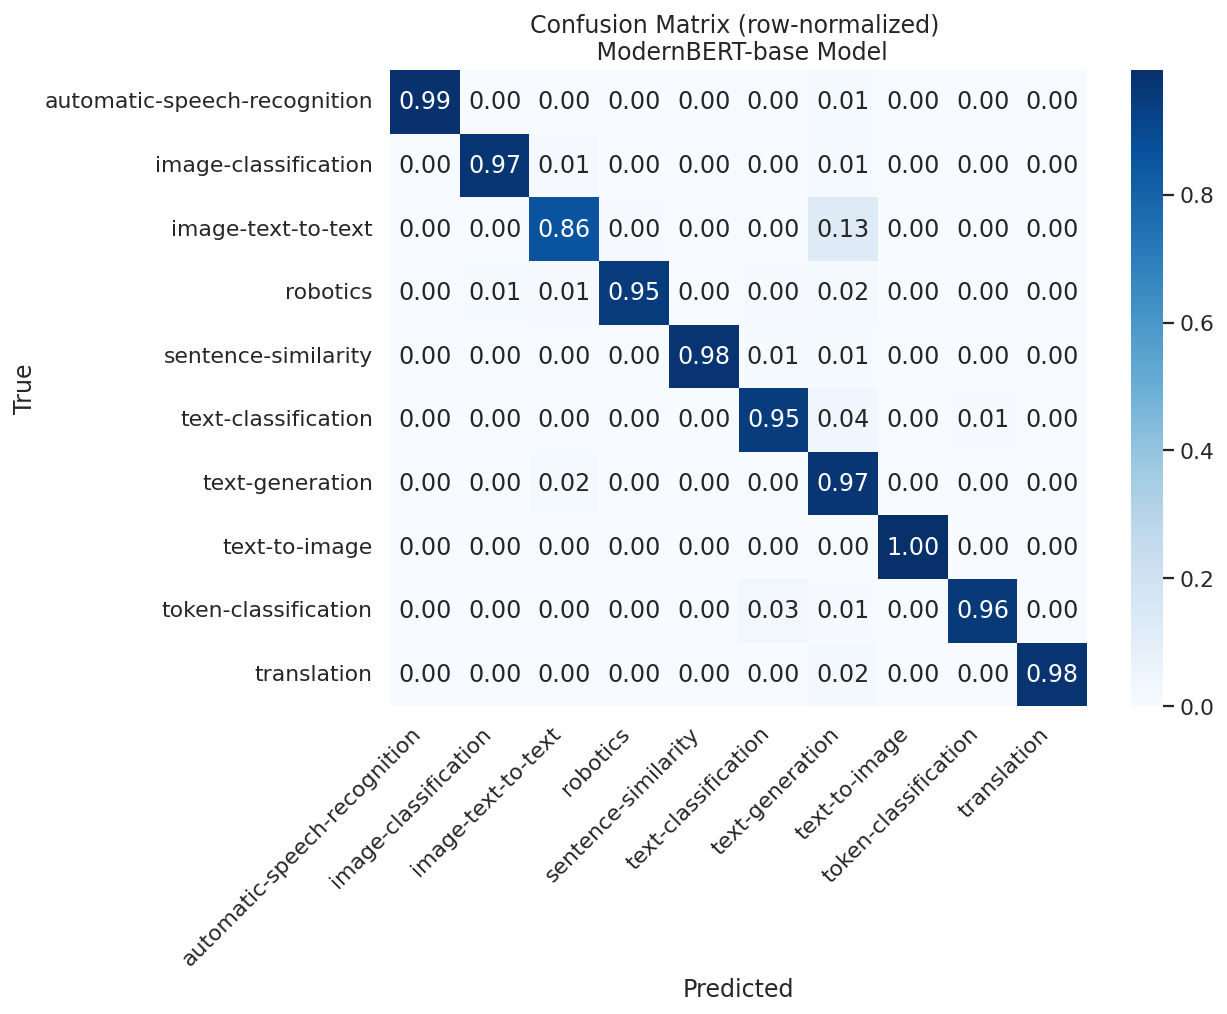

In [22]:
# Confusion Matrix - recall
cm = confusion_matrix(true_labels, preds, normalize="true")
labels = class_names

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (row-normalized) \n ModernBERT-base Model")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
fig.savefig(f'{DRIVE_DIR_2}/modernbert_confusion_matrix.png', dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# Save all the results so don't have to re-run the ablation loop

# 1. Saving ModernBERT ablation results
with open(f'{DRIVE_DIR_2}/modernbert_ablation_results.json', 'w') as f:
    json.dump(ablation_results, f, indent=2)
print("Saved modernbert_ablation_results.json")

# Copy local checkpoint folders for each fraction to Drive
for i in [25, 50, 75, 100]:
    local_dir = f'./results_{i}pct'
    if os.path.exists(local_dir):
        checkpoints = [d for d in os.listdir(local_dir) if d.startswith('checkpoint')]
        if checkpoints:
            src = os.path.join(local_dir, checkpoints[-1])
            dst = f'{DRIVE_DIR_2}/modernbert_frac_{i}pct'
            shutil.copytree(src, dst, dirs_exist_ok=True)
            print(f"Copied {src} -> {dst}")
    else:
        print(f"No local dir found for {i}%, skipping")

# Saving test preds and classification report
if 'preds' in globals() and 'true_labels' in globals():
    np.save(f'{DRIVE_DIR_2}/modernbert_test_preds.npy', preds)
    np.save(f'{DRIVE_DIR_2}/modernbert_test_true_labels.npy', true_labels)
    report_dict = classification_report(true_labels, preds, target_names=target_names, output_dict=True)
    with open(f'{DRIVE_DIR_2}/modernbert_classification_report.json', 'w') as f:
        json.dump(report_dict, f, indent=2)
    print("Saved ModernBERT predictions and classification report")
else:
    print("preds/true_labels not in memory yet")

Saved modernbert_ablation_results.json
Copied ./results_25pct/checkpoint-907 -> /content/drive/MyDrive/266-pipeline-tag-prediction/modernbert_frac_25pct
Copied ./results_50pct/checkpoint-1813 -> /content/drive/MyDrive/266-pipeline-tag-prediction/modernbert_frac_50pct
Copied ./results_75pct/checkpoint-2719 -> /content/drive/MyDrive/266-pipeline-tag-prediction/modernbert_frac_75pct
Copied ./results_100pct/checkpoint-3626 -> /content/drive/MyDrive/266-pipeline-tag-prediction/modernbert_frac_100pct
Saved ModernBERT predictions and classification report
